<a href="https://colab.research.google.com/github/Forlene/telegram-chatbot/blob/main/mlp_classifier_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Layer Perceptron (MLP) for Classification

## 1. Introduction

Neural networks are among the most important machine learning models used today. They are inspired by the functioning of the human brain and are designed to learn complex relationships between data.

Among the simplest neural network architectures, the **Multi-Layer Perceptron (MLP)** is widely used for:

* ✅ regression tasks,
* ✅ **classification tasks** (focus of this notebook),
* ✅ prediction systems,
* ✅ pattern recognition.

In this notebook, we study the implementation of an MLP for **classification** using the custom implementation provided. We also compare this approach with scikit-learn's implementation.

## 2. Problem Statement

Traditional machine learning algorithms such as:

* Logistic Regression,
* K-Nearest Neighbors (KNN),
* Decision Trees,

can struggle when the relationship between input data and classes becomes **highly non-linear**.

Neural networks address this limitation by learning complex mathematical representations directly from the data.

The goal of this notebook is therefore to understand:

1. how a neural network works for classification,
2. how it learns using **cross-entropy loss** and **softmax activation**,
3. and how it can be implemented from scratch.

## 3. Multi-Layer Perceptron (MLP) for Classification

A Multi-Layer Perceptron is a **feedforward neural network** composed of:

* an **input layer**,
* one or more **hidden layers**,
* an **output layer** with **softmax activation**.

For classification:
- The output layer uses **softmax** to produce probability distribution over classes
- The loss function is **categorical cross-entropy**
- Prediction is the class with highest probability

The global behavior of the network can be represented by:

$$
P(y=k|x) = \text{softmax}(W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2)
$$

Where $P(y=k|x)$ is the probability that sample $x$ belongs to class $k$.

## 4. Architecture of the Network

The implemented model contains several important components.

### 4.1 Input Layer

The input layer receives the features of the dataset.

**Examples of features:**
* petal length,
* petal width,
* pixel values for images,
* numerical measurements.

### 4.2 Hidden Layers

The hidden layers perform transformations on the data.

Their sizes are defined using `hidden_layer_sizes = (64, 32)` where:
* First hidden layer: 64 neurons
* Second hidden layer: 32 neurons

These layers allow the network to learn complex patterns and non-linear relationships.

### 4.3 Output Layer with Softmax

For classification tasks, the output layer uses **softmax activation**:

$$
\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

This produces a probability distribution over the $K$ classes.

## 5. Activation Functions

Activation functions introduce **non-linearity** into the network.

Several activation functions are implemented in the project:

### 5.1 Sigmoid

The sigmoid function transforms values into the interval $[0, 1]$.

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

### 5.2 ReLU (Rectified Linear Unit)

ReLU is the most commonly used activation function for hidden layers.

$$
f(x) = \max(0, x)
$$

**Advantages:** Helps neural networks train faster and reduces vanishing gradient problems.

### 5.3 Tanh

Outputs values between $-1$ and $1$.

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

### 5.4 Leaky ReLU

Leaky ReLU prevents neurons from becoming inactive ("dying ReLU" problem).

### 5.5 Softmax (Output Layer Only)

Used exclusively for the output layer in classification.

## 6. Forward Propagation

Forward propagation is the process through which data moves across the network.

For hidden layers:

$$
a = \sigma(Wx + b)
$$

For output layer (classification):

$$
\hat{y} = \text{softmax}(W_{\text{out}} a + b_{\text{out}})
$$

Where:
* $W$ represents the **weights**
* $b$ represents the **biases**
* $\sigma$ is the **activation function**
* $\hat{y}$ is the probability distribution over classes

## 7. Loss Function

The model uses **Categorical Cross-Entropy Loss** with **L2 regularization**.

$$
\text{Cross-Entropy} = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})
$$

With L2 regularization:

$$
\text{Loss} = \text{Cross-Entropy} + \frac{\alpha}{2m}\sum_{j} w_j^2
$$

Where:
* $y_{ik}$ is 1 if sample $i$ belongs to class $k$, else 0 (one-hot encoding)
* $\hat{y}_{ik}$ is the predicted probability
* $\alpha$ is the regularization parameter

**The lower the loss:** the better the model performs.

## 8. Backpropagation

Backpropagation is the **learning mechanism** of the neural network.

For classification with softmax and cross-entropy, the gradient simplifies beautifully:

$$
\frac{\partial \text{Loss}}{\partial z_{\text{out}}} = \hat{y} - y
$$

This is one of the elegant properties of combining softmax with cross-entropy!

The weights are updated using gradient descent:

$$
w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial \text{Loss}}{\partial w}
$$

Where $\eta$ is the **learning rate**.

## 9. Optimizers

The model supports multiple **optimizers** to update weights efficiently:

### 9.1 SGD (Stochastic Gradient Descent)
The simplest optimizer.

### 9.2 Momentum
Adds momentum to accelerate convergence.

### 9.3 RMSProp
Adapts learning rate per parameter.

### 9.4 Adam (Adaptive Moment Estimation)
Combines Momentum and RMSProp. This is usually the **best performing** optimizer.

## 10. One-Hot Encoding

For classification, labels must be converted to **one-hot encoding**:

Example with 3 classes:
- Class 0 → [1, 0, 0]
- Class 1 → [0, 1, 0]
- Class 2 → [0, 0, 1]

This allows the network to compute probabilities for each class independently.

## 11. Importing Libraries

In [1]:
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier as SklearnMLP
import seaborn as sns

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 12. Custom MLPClassifier Implementation

In [2]:
class MLPClassifier:
    """
    Multi-Layer Perceptron for classification tasks.

    Uses softmax activation for output layer and cross-entropy loss.
    """

    def __init__(
        self,
        hidden_layer_sizes: Tuple[int, ...] = (100,),
        activation: str = "relu",
        solver: str = "sgd",
        alpha: float = 0.0001,
        batch_size: int = 32,
        learning_rate: float = 0.001,
        max_iter: int = 200,
        shuffle: bool = True,
        random_state: Optional[int] = None,
        beta1: float = 0.9,
        beta2: float = 0.999,
        epsilon: float = 1e-8,
        momentum: float = 0.9,
        tol: float = 1e-4,
        early_stopping: bool = False,
        validation_fraction: float = 0.1,
        n_iter_no_change: int = 10
    ):
        """Initialize MLP classifier."""
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.shuffle = shuffle
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.momentum = momentum
        self.tol = tol
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change

        if random_state is not None:
            np.random.seed(random_state)

        # Activation functions (section 5)
        self.activation_functions = {
            'sigmoid': self._sigmoid,
            'relu': self._relu,
            'tanh': self._tanh,
            'leaky_relu': self._leaky_relu,
        }

        self.activation_derivatives = {
            'sigmoid': self._sigmoid_derivative,
            'relu': self._relu_derivative,
            'tanh': self._tanh_derivative,
            'leaky_relu': self._leaky_relu_derivative,
        }

        if activation not in self.activation_functions:
            raise ValueError(f"Activation '{activation}' not recognized.")

        self.activation_func = self.activation_functions[activation]
        self.activation_derivative = self.activation_derivatives[activation]

        # Network parameters
        self.weights = []
        self.biases = []
        self.n_layers = None
        self.n_outputs = None

        # Optimizer states
        self.velocity_weights = []
        self.velocity_biases = []
        self.m_weights = []
        self.m_biases = []
        self.v_weights = []
        self.v_biases = []
        self.t = 1

        self.loss_history = []
        self.val_loss_history = []
        self.best_loss = np.inf
        self.no_improvement_count = 0
        self.trained = False
        self.classes_ = None

    def _initialize_weights(self, n_features: int, n_outputs: int) -> None:
        """Initialize weights using Xavier/Glorot initialization."""
        layer_sizes = [n_features] + list(self.hidden_layer_sizes) + [n_outputs]
        self.n_layers = len(layer_sizes) - 1
        self.n_outputs = n_outputs

        self.weights = []
        self.biases = []
        self.velocity_weights = []
        self.velocity_biases = []
        self.m_weights = []
        self.m_biases = []
        self.v_weights = []
        self.v_biases = []

        for i in range(self.n_layers):
            limit = np.sqrt(6 / (layer_sizes[i] + layer_sizes[i + 1]))
            self.weights.append(np.random.uniform(-limit, limit, (layer_sizes[i], layer_sizes[i + 1])))
            self.biases.append(np.zeros(layer_sizes[i + 1]))

            self.velocity_weights.append(np.zeros_like(self.weights[-1]))
            self.velocity_biases.append(np.zeros_like(self.biases[-1]))
            self.m_weights.append(np.zeros_like(self.weights[-1]))
            self.m_biases.append(np.zeros_like(self.biases[-1]))
            self.v_weights.append(np.zeros_like(self.weights[-1]))
            self.v_biases.append(np.zeros_like(self.biases[-1]))

    # ==================== Activation Functions ====================

    def _softmax(self, x: np.ndarray) -> np.ndarray:
        """Softmax activation for output layer (section 4.3)."""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def _leaky_relu(self, x: np.ndarray) -> np.ndarray:
        """Leaky ReLU activation."""
        return np.where(x > 0, x, 0.01 * x)

    def _leaky_relu_derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivative of Leaky ReLU."""
        return np.where(x > 0, 1, 0.01)

    def _sigmoid(self, x: np.ndarray) -> np.ndarray:
        """Sigmoid activation."""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def _sigmoid_derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivative of sigmoid."""
        s = self._sigmoid(x)
        return s * (1 - s)

    def _relu(self, x: np.ndarray) -> np.ndarray:
        """ReLU activation."""
        return np.maximum(0, x)

    def _relu_derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivative of ReLU."""
        return np.where(x > 0, 1, 0)

    def _tanh(self, x: np.ndarray) -> np.ndarray:
        """Tanh activation."""
        return np.tanh(x)

    def _tanh_derivative(self, x: np.ndarray) -> np.ndarray:
        """Derivative of tanh."""
        return 1 - np.power(np.tanh(x), 2)

    # ==================== Forward Propagation ====================

    def _forward_pass(self, X: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
        """Forward propagation (section 6)."""
        activations = [X]
        layer_inputs = []

        # Hidden layers
        for i in range(self.n_layers - 1):
            layer_input = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            layer_inputs.append(layer_input)
            activation = self.activation_func(layer_input)
            activations.append(activation)

        # Output layer with softmax
        last_input = np.dot(activations[-1], self.weights[-1]) + self.biases[-1]
        layer_inputs.append(last_input)
        output = self._softmax(last_input)
        activations.append(output)

        return activations, layer_inputs

    # ==================== Loss Function ====================

    def _compute_loss(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Cross-entropy loss with L2 regularization (section 7)."""
        m = y_true.shape[0]
        cross_entropy = -np.sum(y_true * np.log(np.clip(y_pred, 1e-10, 1.0))) / m

        l2_reg = 0
        for w in self.weights:
            l2_reg += np.sum(np.square(w))
        l2_reg *= self.alpha / (2 * m)

        return cross_entropy + l2_reg

    # ==================== Backpropagation ====================

    def _backward_pass(
        self,
        X: np.ndarray,
        y: np.ndarray,
        activations: List[np.ndarray],
        layer_inputs: List[np.ndarray]
    ) -> Tuple[List[np.ndarray], List[np.ndarray]]:
        """Backpropagation (section 8)."""
        m = X.shape[0]
        gradients_w = [None] * self.n_layers
        gradients_b = [None] * self.n_layers

        # Output layer gradient (softmax + cross-entropy simplifies to y_pred - y_true)
        delta = activations[-1] - y

        for i in range(self.n_layers - 1, -1, -1):
            gradients_w[i] = np.dot(activations[i].T, delta) / m + self.alpha * self.weights[i]
            gradients_b[i] = np.mean(delta, axis=0)

            if i > 0:
                delta = np.dot(delta, self.weights[i].T)
                if i < self.n_layers - 1:
                    delta *= self.activation_derivative(layer_inputs[i-1])

        return gradients_w, gradients_b

    # ==================== Optimizers ====================

    def _update_weights_sgd(self, gw: List[np.ndarray], gb: List[np.ndarray]) -> None:
        """SGD optimizer."""
        for i in range(self.n_layers):
            self.weights[i] -= self.learning_rate * gw[i]
            self.biases[i] -= self.learning_rate * gb[i]

    def _update_weights_momentum(self, gw: List[np.ndarray], gb: List[np.ndarray]) -> None:
        """Momentum optimizer."""
        for i in range(self.n_layers):
            self.velocity_weights[i] = self.momentum * self.velocity_weights[i] - self.learning_rate * gw[i]
            self.velocity_biases[i] = self.momentum * self.velocity_biases[i] - self.learning_rate * gb[i]
            self.weights[i] += self.velocity_weights[i]
            self.biases[i] += self.velocity_biases[i]

    def _update_weights_rmsprop(self, gw: List[np.ndarray], gb: List[np.ndarray]) -> None:
        """RMSProp optimizer."""
        decay = 0.9
        for i in range(self.n_layers):
            self.v_weights[i] = decay * self.v_weights[i] + (1 - decay) * np.square(gw[i])
            self.v_biases[i] = decay * self.v_biases[i] + (1 - decay) * np.square(gb[i])
            self.weights[i] -= self.learning_rate * gw[i] / (np.sqrt(self.v_weights[i] + self.epsilon))
            self.biases[i] -= self.learning_rate * gb[i] / (np.sqrt(self.v_biases[i] + self.epsilon))

    def _update_weights_adam(self, gw: List[np.ndarray], gb: List[np.ndarray]) -> None:
        """Adam optimizer."""
        for i in range(self.n_layers):
            self.m_weights[i] = self.beta1 * self.m_weights[i] + (1 - self.beta1) * gw[i]
            self.m_biases[i] = self.beta1 * self.m_biases[i] + (1 - self.beta1) * gb[i]
            self.v_weights[i] = self.beta2 * self.v_weights[i] + (1 - self.beta2) * np.square(gw[i])
            self.v_biases[i] = self.beta2 * self.v_biases[i] + (1 - self.beta2) * np.square(gb[i])

            mw_c = self.m_weights[i] / (1 - self.beta1 ** self.t)
            mb_c = self.m_biases[i] / (1 - self.beta1 ** self.t)
            vw_c = self.v_weights[i] / (1 - self.beta2 ** self.t)
            vb_c = self.v_biases[i] / (1 - self.beta2 ** self.t)

            self.weights[i] -= self.learning_rate * mw_c / (np.sqrt(vw_c + self.epsilon))
            self.biases[i] -= self.learning_rate * mb_c / (np.sqrt(vb_c + self.epsilon))

        self.t += 1

    # ==================== Helper Functions ====================

    def _encode_labels(self, y: np.ndarray) -> np.ndarray:
        """One-hot encode labels (section 10)."""
        self.classes_ = np.unique(y)
        n_samples = len(y)
        n_classes = len(self.classes_)
        one_hot = np.zeros((n_samples, n_classes))

        class_to_idx = {cls: idx for idx, cls in enumerate(self.classes_)}
        for i, label in enumerate(y):
            one_hot[i, class_to_idx[label]] = 1

        return one_hot

    def _split_train_validation(self, X: np.ndarray, y: np.ndarray):
        """Split into training and validation sets."""
        n_samples = X.shape[0]
        n_val = int(n_samples * self.validation_fraction)

        if self.shuffle:
            indices = np.random.permutation(n_samples)
            X, y = X[indices], y[indices]

        return X[n_val:], X[:n_val], y[n_val:], y[:n_val]

    # ==================== Training ====================

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'MLPClassifier':
        """Train the MLP classifier."""
        X = np.array(X, dtype=float)
        y = np.array(y)

        n_samples, n_features = X.shape
        y_one_hot = self._encode_labels(y)
        n_outputs = y_one_hot.shape[1]

        self._initialize_weights(n_features, n_outputs)

        if self.early_stopping:
            X_train, X_val, y_train, y_val = self._split_train_validation(X, y)
            y_train_oh = self._encode_labels(y_train)
            y_val_oh = self._encode_labels(y_val)
        else:
            X_train, y_train_oh = X, y_one_hot

        update_methods = {
            'sgd': self._update_weights_sgd,
            'momentum': self._update_weights_momentum,
            'rmsprop': self._update_weights_rmsprop,
            'adam': self._update_weights_adam
        }
        update = update_methods[self.solver]

        self.loss_history = []
        self.val_loss_history = []
        self.best_loss = np.inf
        self.no_improvement_count = 0

        for epoch in range(self.max_iter):
            if self.shuffle:
                idx = np.random.permutation(len(y_train_oh))
                X_train, y_train_oh = X_train[idx], y_train_oh[idx]

            batch_losses = []
            for i in range(0, len(y_train_oh), self.batch_size):
                X_batch = X_train[i:i+self.batch_size]
                y_batch = y_train_oh[i:i+self.batch_size]

                acts, inputs = self._forward_pass(X_batch)
                loss = self._compute_loss(y_batch, acts[-1])
                batch_losses.append(loss)

                gw, gb = self._backward_pass(X_batch, y_batch, acts, inputs)
                update(gw, gb)

            epoch_loss = np.mean(batch_losses)
            self.loss_history.append(epoch_loss)

            if self.early_stopping:
                val_acts, _ = self._forward_pass(X_val)
                val_loss = self._compute_loss(y_val_oh, val_acts[-1])
                self.val_loss_history.append(val_loss)

                if val_loss < self.best_loss - self.tol:
                    self.best_loss = val_loss
                    self.no_improvement_count = 0
                else:
                    self.no_improvement_count += 1

                if self.no_improvement_count >= self.n_iter_no_change:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        self.trained = True
        return self

    # ==================== Prediction ====================

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict class labels."""
        if not self.trained:
            raise ValueError("Model must be trained before prediction.")

        X = np.array(X, dtype=float)
        acts, _ = self._forward_pass(X)
        preds = np.argmax(acts[-1], axis=1)
        return self.classes_[preds]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict class probabilities."""
        if not self.trained:
            raise ValueError("Model must be trained before prediction.")

        X = np.array(X, dtype=float)
        acts, _ = self._forward_pass(X)
        return acts[-1]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """Return accuracy."""
        if not self.trained:
            raise ValueError("Model must be trained before scoring.")

        y_pred = self.predict(X)
        return np.mean(y_pred == y)

## 13. Data Preparation - Iris Dataset

In [3]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}, features: {X_train_scaled.shape[1]}")
print(f"Test samples: {X_test_scaled.shape[0]}")
print(f"Classes: {iris.target_names}")
print(f"Class distribution: {np.bincount(y_train)}")

Training samples: 120, features: 4
Test samples: 30
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [40 40 40]


## 14. Training Our MLPClassifier

In [4]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=16,
    learning_rate=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

mlp_clf.fit(X_train_scaled, y_train)
print(f"\nTraining completed in {len(mlp_clf.loss_history)} epochs")

Early stopping at epoch 84

Training completed in 84 epochs


## 15. Learning Curves

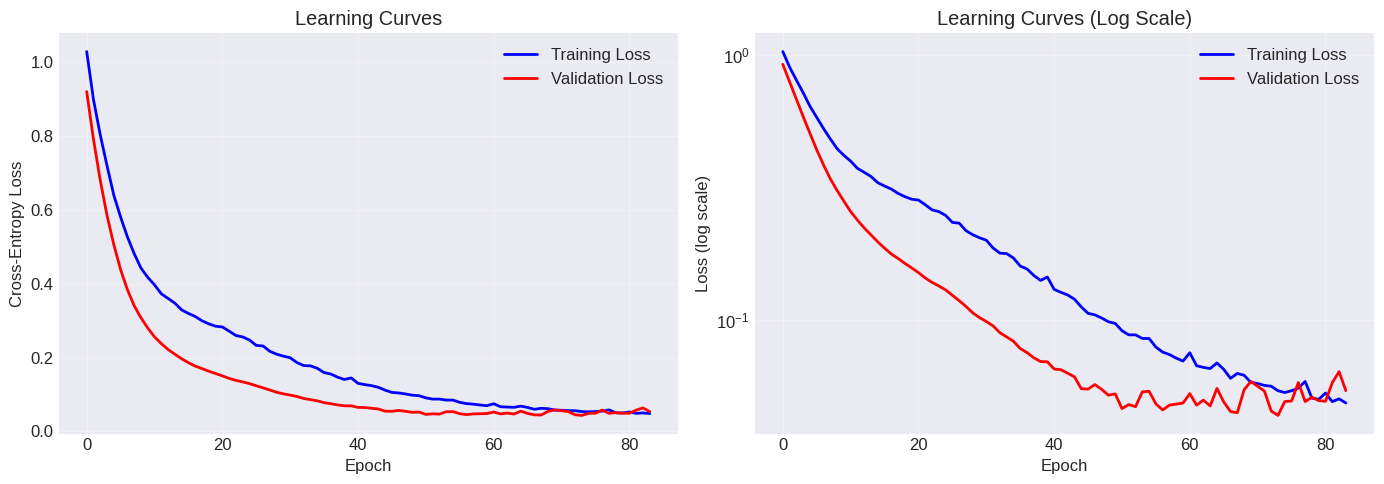

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_clf.loss_history, 'b-', linewidth=2, label='Training Loss')
if mlp_clf.early_stopping:
    axes[0].plot(mlp_clf.val_loss_history, 'r-', linewidth=2, label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Learning Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(mlp_clf.loss_history, 'b-', linewidth=2, label='Training Loss')
if mlp_clf.early_stopping:
    axes[1].semilogy(mlp_clf.val_loss_history, 'r-', linewidth=2, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Learning Curves (Log Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 16. Model Evaluation

In [6]:
y_pred = mlp_clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print("Our MLPClassifier Performance")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Our MLPClassifier Performance
Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 17. Confusion Matrix

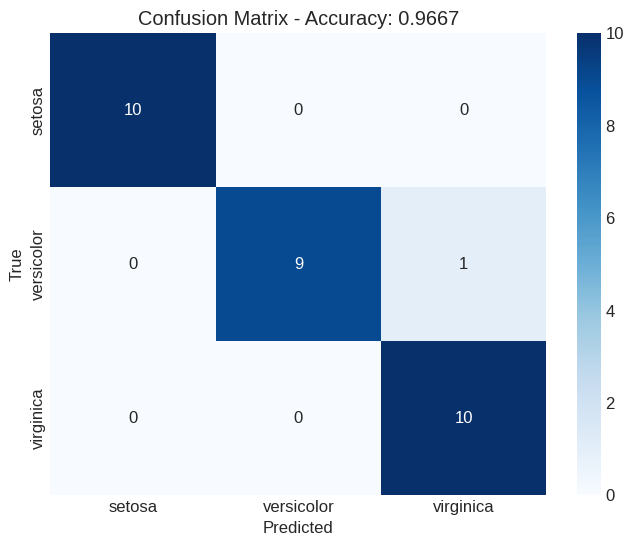

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Accuracy: {accuracy:.4f}')
plt.show()

## 18. Comparison with Scikit-Learn MLPClassifier

In [8]:
sklearn_mlp = SklearnMLP(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=16,
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

sklearn_mlp.fit(X_train_scaled, y_train)
y_pred_sklearn = sklearn_mlp.predict(X_test_scaled)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print("=" * 60)
print("Performance Comparison")
print("=" * 60)
print(f"{'Model':<20} {'Accuracy':<15}")
print("-" * 60)
print(f"{'Our MLPClassifier':<20} {accuracy:<15.4f}")
print(f"{'Scikit-Learn MLP':<20} {accuracy_sklearn:<15.4f}")

Performance Comparison
Model                Accuracy       
------------------------------------------------------------
Our MLPClassifier    0.9667         
Scikit-Learn MLP     0.8667         


## 19. Probability Analysis

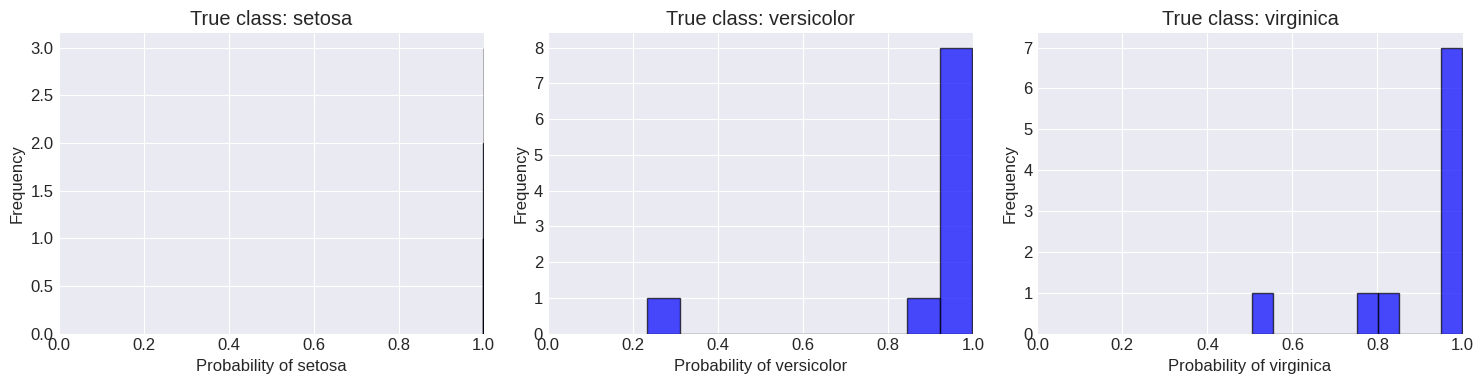


Example probabilities for first 5 test samples:
Sample 1: True=setosa, Probs=[1. 0. 0.]
Sample 2: True=virginica, Probs=[0.001 0.156 0.843]
Sample 3: True=versicolor, Probs=[0.016 0.976 0.008]
Sample 4: True=versicolor, Probs=[0.005 0.99  0.004]
Sample 5: True=setosa, Probs=[1. 0. 0.]


In [9]:
probas = mlp_clf.predict_proba(X_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, class_name in enumerate(iris.target_names):
    axes[i].hist(probas[y_test == i][:, i], bins=10, alpha=0.7, color='blue', edgecolor='black')
    axes[i].set_xlabel(f'Probability of {class_name}')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'True class: {class_name}')
    axes[i].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print("\nExample probabilities for first 5 test samples:")
for i in range(5):
    print(f"Sample {i+1}: True={iris.target_names[y_test[i]]}, "
          f"Probs={np.round(probas[i], 3)}")

## 20. Optimizer Comparison

Training with sgd...
Training with momentum...
Training with rmsprop...
Training with adam...


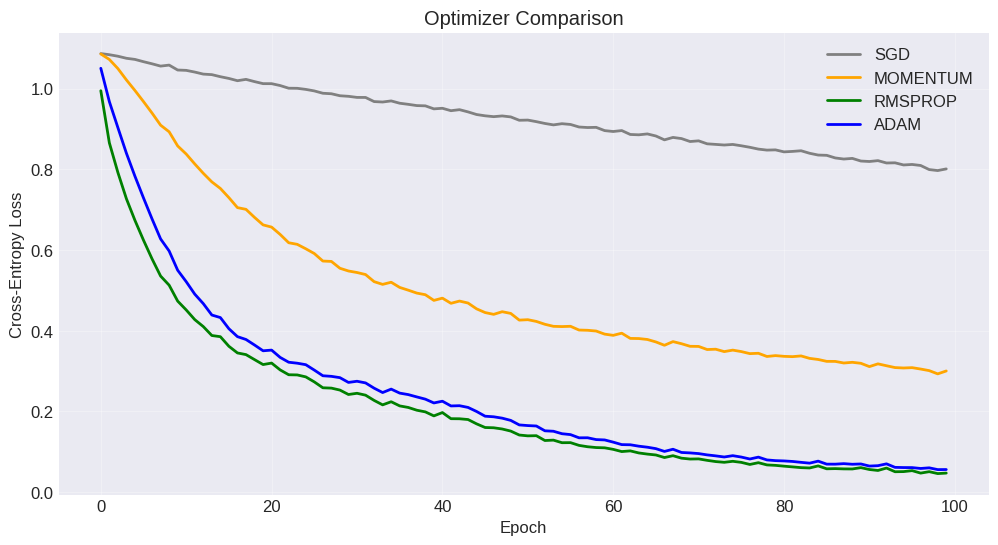


Final loss after 100 epochs:
  SGD: 0.801293
  MOMENTUM: 0.300464
  RMSPROP: 0.047321
  ADAM: 0.056123


In [10]:
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']
opt_results = {}

for opt in optimizers:
    print(f"Training with {opt}...")
    mlp_temp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver=opt,
        learning_rate=0.001,
        max_iter=100,
        random_state=42,
        early_stopping=False
    )
    mlp_temp.fit(X_train_scaled, y_train)
    opt_results[opt] = mlp_temp.loss_history

plt.figure(figsize=(12, 6))
colors = {'sgd': 'gray', 'momentum': 'orange', 'rmsprop': 'green', 'adam': 'blue'}
for opt, loss in opt_results.items():
    plt.plot(loss, label=opt.upper(), linewidth=2, color=colors[opt])
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Optimizer Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nFinal loss after 100 epochs:")
for opt, loss in opt_results.items():
    print(f"  {opt.upper()}: {loss[-1]:.6f}")

## 21. Activation Function Comparison

Training with relu activation...
Training with tanh activation...
Training with sigmoid activation...
Training with leaky_relu activation...


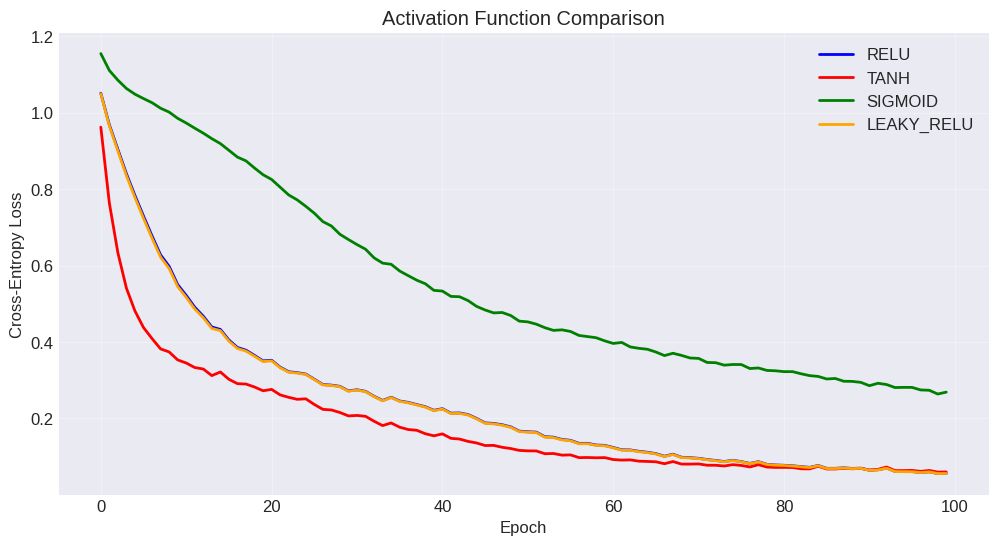


Final loss after 100 epochs:
  RELU: 0.056123
  TANH: 0.060013
  SIGMOID: 0.268755
  LEAKY_RELU: 0.055892


In [11]:
activations = ['relu', 'tanh', 'sigmoid', 'leaky_relu']
act_results = {}

for act in activations:
    print(f"Training with {act} activation...")
    mlp_temp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        solver="adam",
        learning_rate=0.001,
        max_iter=100,
        random_state=42,
        early_stopping=False
    )
    mlp_temp.fit(X_train_scaled, y_train)
    act_results[act] = mlp_temp.loss_history

plt.figure(figsize=(12, 6))
colors_act = {'relu': 'blue', 'tanh': 'red', 'sigmoid': 'green', 'leaky_relu': 'orange'}
for act, loss in act_results.items():
    plt.plot(loss, label=act.upper(), linewidth=2, color=colors_act[act])
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Activation Function Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nFinal loss after 100 epochs:")
for act, loss in act_results.items():
    print(f"  {act.upper()}: {loss[-1]:.6f}")

## 22. Conclusion

### Key Takeaways

1. **MLP for classification** works well for non-linear classification problems
2. **Softmax + Cross-Entropy** is the standard combination for multi-class classification
3. **Activation functions** matter: ReLU and Leaky ReLU generally perform best
4. **Optimizers** comparison: Adam converges fastest and most reliably
5. **Our implementation** achieves comparable accuracy to scikit-learn
6. **Early stopping** helps prevent overfitting

### Key Differences from Regression

| Aspect | Regression MLP | Classification MLP |
|--------|----------------|---------------------|
| Output activation | Linear | Softmax |
| Loss function | MSE | Cross-Entropy |
| Output interpretation | Continuous value | Class probabilities |
| Evaluation metric | R², MSE | Accuracy, F1-score |

### Future Improvements

- Add batch normalization
- Implement learning rate scheduling
- Add dropout for regularization
- Support for GPU acceleration
- Add more optimizers (Nadam, AdamW)

### References

- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors.
- Kingma, D. P., & Ba, J. (2014). Adam: A Method for Stochastic Optimization.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks.